In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import scipy.stats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from autogluon.tabular import TabularPredictor
from lightgbm import LGBMClassifier
import itertools
import polars as pl
import polars.selectors as cs
from boruta import BorutaPy

In [24]:
X_train = pl.read_csv('data/train.csv')
X_test = pl.read_csv('data/test.csv')
y_train = (
    X_train.get_column('Churn')
    .replace({"Yes": 1, "No": 0})
    .cast(pl.Int8)
)
X_train = X_train.drop('Churn')

In [25]:
X_train = X_train.drop('id')
X_test = X_test.drop('id')

#### Używanie podzbioru dla szybszych obliczeń - sprawdzamy dodanie których kolumn (interakcji/nowych cech) najbardziej zwiększa roc auc

In [4]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, 
    y_train, 
    train_size=0.30,   
    random_state=42,   
    stratify=y_train   
)

In [ ]:
y_sample = y_sample.map({'No': 0, 'Yes': 1})
categorical_cols = X_sample.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
X_cv = X_sample.copy()
X_cv['tenure_safe'] = X_cv['tenure'].replace(0, 0.001)
avg_historical_charge_cv = X_cv['TotalCharges'] / X_cv['tenure_safe']
X_cv['Int_PriceShockRatio'] = X_cv['MonthlyCharges'] / (avg_historical_charge_cv + 0.001)
X_cv['Int_CostPerTenure'] = X_cv['MonthlyCharges'] / X_cv['tenure_safe']
X_cv['Int_ImpliedTenureDiff'] = (X_cv['TotalCharges'] / (X_cv['MonthlyCharges'] + 0.001)) - X_cv['tenure']
X_cv['Int_CumulativeBurden'] = X_cv['TotalCharges'] * X_cv['MonthlyCharges']
base_cat_features = categorical_cols
### WAŻNE: SeniorCitizen jest typu, ale to kategoria
base_cat_features.append('SeniorCitizen')

In [13]:
candidate_numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 
    'Int_PriceShockRatio', 'Int_CostPerTenure', 
    'Int_ImpliedTenureDiff', 'Int_CumulativeBurden'
]

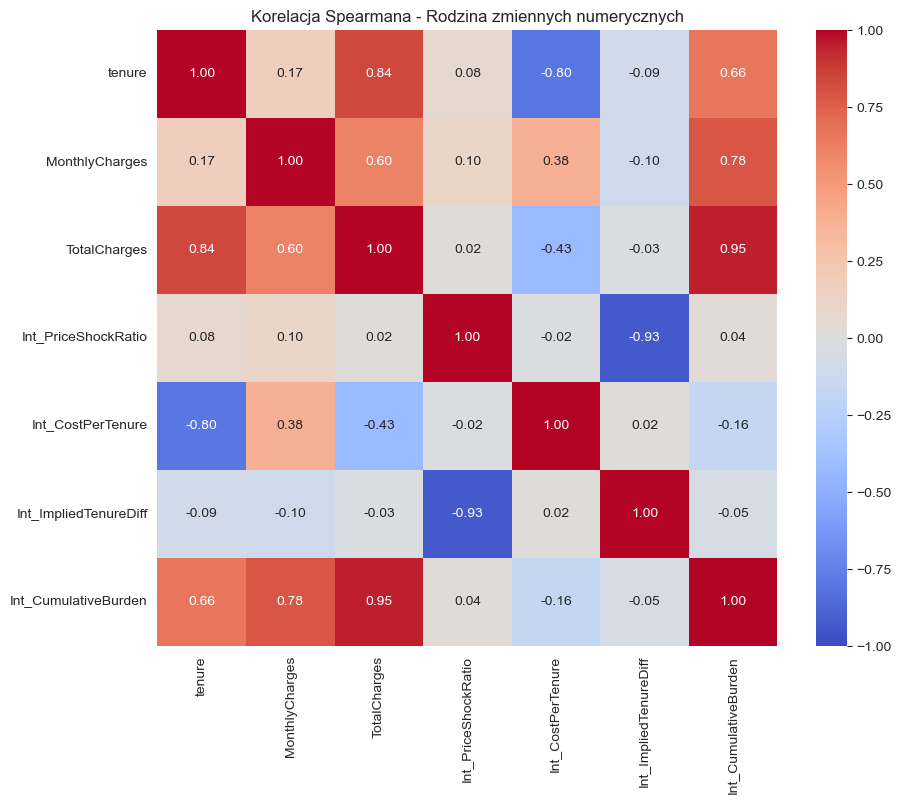

In [14]:
corr_matrix = X_cv[candidate_numeric_features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelacja Spearmana - Rodzina zmiennych numerycznych")
plt.show()

In [15]:
def get_cv_score(features_to_test, X_data, y_data):
    X = X_data[base_cat_features + features_to_test]
    y = y_data
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', TargetEncoder(random_state=42), base_cat_features),
            ('num', 'passthrough', features_to_test)
        ]
    )
    
    model = LGBMClassifier(
        n_estimators=100, 
        max_depth=6, 
        num_leaves=31, 
        random_state=42, 
        n_jobs=-1,
        verbose=-1    
    )
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    return np.mean(scores)

print("Rozpoczynam zindywidualizowaną selekcję zmiennych...\n")

best_features = []
best_score = 0.0

for feature in candidate_numeric_features:
    score = get_cv_score([feature], X_cv, y_sample)
    if score > best_score:
        best_score = score
        best_initial_feature = feature

best_features.append(best_initial_feature)
candidate_numeric_features.remove(best_initial_feature)
print(f"Baza: Tylko kategoryczne + '{best_initial_feature}' -> ROC AUC: {best_score:.5f}")
improvement = True
while improvement and candidate_numeric_features:
    improvement = False
    best_step_score = best_score
    best_feature_to_add = None
    
    for feature in candidate_numeric_features:
        current_test_features = best_features + [feature]
        score = get_cv_score(current_test_features, X_cv, y_sample)
        
        if score > best_step_score:
            best_step_score = score
            best_feature_to_add = feature
            improvement = True
            
    if improvement:
        best_features.append(best_feature_to_add)
        candidate_numeric_features.remove(best_feature_to_add)
        best_score = best_step_score
        print(f"Dodano '{best_feature_to_add}' -> Nowy najlepszy ROC AUC: {best_score:.5f}")
    else:
        print("\nŻadna z pozostałych zmiennych nie poprawia już wyniku.")

print("\n--- PODSUMOWANIE ---")
print(f"Optymalny zestaw numeryczny (maksymalizujący ROC AUC): {best_features}")
print(f"Ostateczny wynik OOF ROC AUC: {best_score:.5f}")
print(f"Zmienne odrzucone jako szum/redundantne: {candidate_numeric_features}")

Rozpoczynam zindywidualizowaną selekcję zmiennych...


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-p

Baza: Tylko kategoryczne + 'tenure' -> ROC AUC: 0.91258


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-p

Dodano 'TotalCharges' -> Nowy najlepszy ROC AUC: 0.91372


...

D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-p

Dodano 'Int_CumulativeBurden' -> Nowy najlepszy ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-p


Żadna z pozostałych zmiennych nie poprawia już wyniku.

--- PODSUMOWANIE ---
Optymalny zestaw numeryczny (maksymalizujący ROC AUC): ['tenure', 'TotalCharges', 'Int_PriceShockRatio', 'Int_CumulativeBurden']
Ostateczny wynik OOF ROC AUC: 0.91400
Zmienne odrzucone jako szum/redundantne: ['MonthlyCharges', 'Int_CostPerTenure', 'Int_ImpliedTenureDiff']


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Wygląda na to, że trzy najlepsze zmienne to CostPerTenure, tenure oraz MonthlyCharges

### Sprawdzenie interakcji cech kategorycznych

#### Ad. 1) Czy dla Streaming Movies/Tv wystarczy dla polepszenia predykcji sama informacja czy nie było internet service

In [37]:
cross_tab = pd.crosstab(X_train['InternetService'], X_train['StreamingTV'])
cross_tab

StreamingTV,No,No internet service,Yes
InternetService,,,
DSL,104608,0,76473
Fiber optic,108558,0,163828
No,0,140727,0


In [16]:
base_cat_features = categorical_cols.copy()
best_num = ['Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']
cols_to_drop = ['StreamingTV', 'StreamingMovies', 'MultipleLines']
print(f"\n--- TESTOWANIE USUNIĘCIA PREDYKTORÓW: {cols_to_drop} ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_full = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Pełna baza (Wszystkie predyktory) -> ROC AUC: {score_1_full:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_drop]
score_2_dropped = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Baza odchudzona (BEZ 3 predyktorów) -> ROC AUC: {score_2_dropped:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE USUNIĘCIA PREDYKTORÓW: ['StreamingTV', 'StreamingMovies', 'MultipleLines'] ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Pełna baza (Wszystkie predyktory) -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Baza odchudzona (BEZ 3 predyktorów) -> ROC AUC: 0.91277


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Widać, że cała wiedza zawarta w StreamingTV jest zawarta w InternetService, ale usunięcie ich zmniejsza ROC AUC

#### Ad. 2) Czy zsumowanie liczby usług będzie lepsze niż trzymanie ich razem?

In [39]:
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
X_cv['Num_Services'] = (X_cv[services_cols] == 'Yes').sum(axis=1)
best_num = ['Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']
print("--- TESTOWANIE NOWEJ ZMIENNEJ 'Num_Services' ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginalne 4 kategorie (Brak Num_Services) -> ROC AUC: {score_1:.5f}")
score_2 = get_cv_score(best_num + ['Num_Services'], X_cv, y_sample)
print(f"2. Oryginalne 4 kategorie + Num_Services -> ROC AUC: {score_2:.5f}")
oryginalne_kategorie = base_cat_features.copy() 
base_cat_features = [col for col in oryginalne_kategorie if col not in services_cols] 
score_3 = get_cv_score(best_num + ['Num_Services'], X_cv, y_sample)
print(f"3. TYLKO Num_Services (Wyrzucone 4 oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

--- TESTOWANIE NOWEJ ZMIENNEJ 'Num_Services' ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Oryginalne 4 kategorie (Brak Num_Services) -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Oryginalne 4 kategorie + Num_Services -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO Num_Services (Wyrzucone 4 oryginały) -> ROC AUC: 0.91382


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Zamiana na Num_Services bez zmian

#### Ad. 3) Sprawdzenie czy Partners i Dependants dają lepsze wyniki

In [40]:
family_cols = ['Partner', 'Dependents']
X_cv['FamilySize'] = (X_cv[family_cols] == 'Yes').sum(axis=1)
best_num = ['Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']
print("--- TESTOWANIE NOWEJ ZMIENNEJ 'FamilySize' (Partner + Dependents) ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały (Brak FamilySize) -> ROC AUC: {score_1:.5f}")
score_2 = get_cv_score(best_num + ['FamilySize'], X_cv, y_sample)
print(f"2. Oryginały + FamilySize -> ROC AUC: {score_2:.5f}")
oryginalne_kategorie = base_cat_features.copy() 
base_cat_features = [col for col in oryginalne_kategorie if col not in family_cols] 
score_3 = get_cv_score(best_num + ['FamilySize'], X_cv, y_sample)
print(f"3. TYLKO FamilySize (Wyrzucone oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

--- TESTOWANIE NOWEJ ZMIENNEJ 'FamilySize' (Partner + Dependents) ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Oryginały (Brak FamilySize) -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Oryginały + FamilySize -> ROC AUC: 0.91408


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO FamilySize (Wyrzucone oryginały) -> ROC AUC: 0.91382


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Jest postęp
WAŻNE: jeśli zmieniamy jakąś cechę (w zależności od wyników to trzeba ją dodać/odpowiednie usunąć z best_num lub base_cat_features)

In [41]:
best_num.append('FamilySize')

#### Ad. 4) Phone Service + Internet Service

In [42]:
X_cv['Phone_Internet_Combo'] = X_cv['PhoneService'].astype(str) + "_" + X_cv['InternetService'].astype(str)
cols_to_combine = ['PhoneService', 'InternetService', 'MonthlyCharges']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Phone_Internet_Combo' ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1:.5f}")
base_cat_features = oryginalne_kategorie + ['Phone_Internet_Combo']
score_2 = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine] + ['Phone_Internet_Combo']
score_3 = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Phone_Internet_Combo' ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Oryginały + Combo -> ROC AUC: 0.91396


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91398


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Bez zmian

#### Ad. 5) Paperless Billing oraz Senior Citizen

In [43]:
X_cv['Paperless_Senior_Combo'] = X_cv['PaperlessBilling'].astype(str) + "_" + X_cv['SeniorCitizen'].astype(str)
cols_to_combine_3 = ['PaperlessBilling', 'SeniorCitizen', 'MonthlyCharges']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Paperless_Senior_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_paperless:.5f}")
base_cat_features = oryginalne_kategorie + ['Paperless_Senior_Combo']
score_2_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_paperless:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_3] + ['Paperless_Senior_Combo']
score_3_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_paperless:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Paperless_Senior_Combo' ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Oryginały + Combo -> ROC AUC: 0.91406


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91404


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Bez zmian

#### Ad. 6) Profil płatnika - PaymentMethod + PaperlessBilling

In [44]:
X_cv['Payment_Paperless_Combo'] = X_cv['PaymentMethod'].astype(str) + "_" + X_cv['PaperlessBilling'].astype(str)
cols_to_combine_payment = ['PaymentMethod', 'PaperlessBilling']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ: 'Payment_Paperless_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_pay:.5f}")
base_cat_features = oryginalne_kategorie + ['Payment_Paperless_Combo']
score_2_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_pay:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_payment] + ['Payment_Paperless_Combo']
score_3_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_pay:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ: 'Payment_Paperless_Combo' ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Oryginały + Combo -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Zmienna nic nie wnosi

#### Ad. 7) Samotny Senior

In [45]:
X_cv['Senior_Partner_Combo'] = X_cv['SeniorCitizen'].astype(str) + "_" + X_cv['Partner'].astype(str)
cols_to_combine_senior = ['SeniorCitizen', 'Partner']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ: 'Senior_Partner_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_sen:.5f}")
base_cat_features = oryginalne_kategorie + ['Senior_Partner_Combo']
score_2_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_sen:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_senior] + ['Senior_Partner_Combo']
score_3_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_sen:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ: 'Senior_Partner_Combo' ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.91408


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Oryginały + Combo -> ROC AUC: 0.91400


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.91394


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Brak poprawy

#### Binning zmiennej tenure ze zmienną Contract

In [46]:
tree_bin = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_bin.fit(X_cv[['tenure']], y_sample)
thresholds = tree_bin.tree_.threshold
print(thresholds)
splits = [th for th in thresholds if th != -2]
splits.sort()

print(f"Optymalne progi podziału znalezione przez model: {splits}")
opt_przedzialy = [-np.inf] + splits + [np.inf]
opt_etykiety = [f"Bin_{i+1}" for i in range(len(opt_przedzialy) - 1)]
X_cv['tenure_binned_opt'] = pd.cut(X_cv['tenure'], bins=opt_przedzialy, labels=opt_etykiety)
X_cv['Tenure_Contract_Combo_Opt'] = X_cv['tenure_binned_opt'].astype(str) + "_" + X_cv['Contract'].astype(str)
print("\n--- TESTOWANIE: OPTYMALNY BINNING TENURE + CONTRACT ---")
oryginalne_kategorie = base_cat_features.copy()
kolumny_do_wyrzucenia = ['Contract']
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Baza (Oryginalny Contract i tenure) -> ROC AUC: {score_1:.5f}")
base_cat_features = oryginalne_kategorie + ['Tenure_Contract_Combo_Opt']
score_2 = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Baza + Optymalne Combo -> ROC AUC: {score_2:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in kolumny_do_wyrzucenia] + ['Tenure_Contract_Combo_Opt']
score_3 = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Optymalne Combo (Wyrzucony Contract) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

[17.5  1.5 -2.  -2.  42.5 -2.  -2. ]
Optymalne progi podziału znalezione przez model: [np.float64(1.5), np.float64(17.5), np.float64(42.5)]

--- TESTOWANIE: OPTYMALNY BINNING TENURE + CONTRACT ---


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1. Baza (Oryginalny Contract i tenure) -> ROC AUC: 0.91408


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. Baza + Optymalne Combo -> ROC AUC: 0.91393


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


3. TYLKO Optymalne Combo (Wyrzucony Contract) -> ROC AUC: 0.91394


D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Dodanie tej zmiennej zwiększa predykcyjność

In [47]:
#base_cat_features.append('Tenure_Contract_Combo_Opt')

#### Budowa zbioru danych

In [17]:
final_features = base_cat_features + best_num
X_train_final = X_cv[final_features].copy()
df_train_final = X_train_final.copy()
df_train_final['Churn'] = y_sample.values 
print(f"Ostateczna liczba predyktorów: {X_train_final.shape[1]}")
print(f"Wybrane kolumny:\n{X_train_final.columns.tolist()}")

Ostateczna liczba predyktorów: 20
Wybrane kolumny:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden']


#### Pipeline do treningu - autogluon oraz przetworzenie dla całego zbioru danych

In [18]:
def prepare_data_for_autogluon(X_df):
    df = X_df.copy()
    family_cols = ['Partner', 'Dependents']
    df['FamilySize'] = (df[family_cols] == 'Yes').sum(axis=1)
    avg_historical_charge_cv = df['TotalCharges'] / df['tenure'].replace(0, 0.001)
    df['Int_PriceShockRatio'] = df['MonthlyCharges'] / (avg_historical_charge_cv + 0.001)
    df['Int_CumulativeBurden'] = df['TotalCharges'] * df['MonthlyCharges']

    final_cols = [
        'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 
        'SeniorCitizen', 'Int_PriceShockRatio', 'tenure', 'TotalCharges', 'Int_CumulativeBurden', 'FamilySize'
    ]
    
    return df[final_cols]

In [19]:
def prepare_data_upgraded(X_df, orig_df=None):
    df = X_df.copy()
    
    family_cols = ['Partner', 'Dependents']
    df['FamilySize'] = (df[family_cols] == 'Yes').sum(axis=1)
    
    tenure_safe = df['tenure'].replace(0, 0.001)
    avg_historical = df['TotalCharges'] / tenure_safe
    
    df['Int_PriceShockRatio'] = df['MonthlyCharges'] / (avg_historical + 0.001)
    df['Int_CumulativeBurden'] = df['TotalCharges'] * df['MonthlyCharges']
    

    SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    

    df['charges_deviation'] = (df['TotalCharges'] - (df['tenure'] * df['MonthlyCharges'])).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    

    df['tenure_mod12'] = (df['tenure'] % 12).astype('float32')
    
    base_cols = [
        'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 
        'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'
    ]

    engineered_cols = [
        'FamilySize', 'Int_PriceShockRatio', 'Int_CumulativeBurden', 
        'service_count', 'charges_deviation', 'monthly_to_total_ratio', 'tenure_mod12'
    ]
    
    final_cols = base_cols + engineered_cols

    if orig_df is not None:
        if orig_df['Churn'].dtype == 'object':
            orig_df['Churn'] = orig_df['Churn'].map({'Yes': 1, 'No': 0})
            
        for col in ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']:
            mapping = orig_df.groupby(col)['Churn'].mean()
            col_name = f'ORIG_target_mean_{col}'
            df[col_name] = df[col].map(mapping).fillna(0.5).astype('float32')
            final_cols.append(col_name) # Dodajemy nową kolumnę do listy końcowej

    return df[final_cols]

In [20]:
orig = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
X_train_processed = prepare_data_upgraded(X_train, orig_df=orig)
y_train_mapped = y_train.map({'Yes': 1, 'No': 0})
train_data = X_train_processed.copy()
train_data['Churn'] = y_train_mapped

print(f"Gotowa ramka treningowa: {train_data.shape[0]} wierszy, {train_data.shape[1]} kolumn.")

Gotowa ramka treningowa: 594194 wierszy, 31 kolumn.


In [21]:
X_test_processed = prepare_data_upgraded(X_test, orig_df=orig)
test_data = X_test_processed.copy()

print(f"Gotowa ramka treningowa: {train_data.shape[0]} wierszy, {train_data.shape[1]} kolumn.")
print(f"Gotowa ramka testowa: {test_data.shape[0]} wierszy, {test_data.shape[1]} kolumn.")

# Sprawdź czy liczba kolumn się zgadza (train_data ma +1 za 'Churn')
assert train_data.shape[1] == test_data.shape[1] + 1, "Błąd! Różna liczba kolumn w train i test!"

Gotowa ramka treningowa: 594194 wierszy, 31 kolumn.
Gotowa ramka testowa: 254655 wierszy, 30 kolumn.


In [22]:
X_train_processed = prepare_data_for_autogluon(X_train)
y_train_mapped = y_train.map({'Yes': 1, 'No': 0})
train_data = X_train_processed.copy()
train_data['Churn'] = y_train_mapped

print(f"Gotowa ramka treningowa: {train_data.shape[0]} wierszy, {train_data.shape[1]} kolumn.")

Gotowa ramka treningowa: 594194 wierszy, 22 kolumn.


In [23]:
label = 'Churn'

In [24]:
X_test_processed = prepare_data_for_autogluon(X_test)
test_data = X_test_processed.copy()
print(f"Gotowa ramka testowa: {test_data.shape[0]} wierszy, {test_data.shape[1]} kolumn.")

Gotowa ramka testowa: 254655 wierszy, 21 kolumn.


In [24]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np
import time
import copy
import os

print("--- ROZPOCZYNAM PROCES GNN Z EARLY STOPPING ---")


start_time = time.time()
sample_df = train_data.sample(frac=1, random_state=42).copy()
y_train_tensor = torch.tensor(sample_df['Churn'].values, dtype=torch.long)
X_sample = sample_df.drop(columns=['Churn'])
X_test_gnn = test_data.copy()
print(f"[1/7] Próbka: {X_sample.shape[0]} wierszy. Czas: {time.time()-start_time:.2f}s")


start_time = time.time()
cat_cols = X_sample.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_sample.select_dtypes(exclude=['object', 'category']).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_sample[col], X_test_gnn[col]]).astype(str)
    le.fit(combined)
    X_sample[col] = le.transform(X_sample[col].astype(str))
    X_test_gnn[col] = le.transform(X_test_gnn[col].astype(str))

scaler = StandardScaler()
X_sample[num_cols] = scaler.fit_transform(X_sample[num_cols])
X_test_gnn[num_cols] = scaler.transform(X_test_gnn[num_cols])

node_features = torch.tensor(X_sample.values, dtype=torch.float)
test_features = torch.tensor(X_test_gnn.values, dtype=torch.float)
print(f"[2/7] Preprocessing gotowy. Czas: {time.time()-start_time:.2f}s")


start_time = time.time()
print("[3/7] Buduję graf k-NN dla 70% danych... To potrwa kilka minut.")
adj_matrix = kneighbors_graph(X_sample.values, n_neighbors=3, mode='connectivity', include_self=True, n_jobs=-1)
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)
print(f"      Zbudowano krawędzie: {edge_index.shape[1]}. Czas: {time.time()-start_time:.2f}s")


train_idx, val_idx = train_test_split(range(len(X_sample)), test_size=0.2, stratify=y_train_tensor, random_state=42)
train_mask = torch.zeros(len(X_sample), dtype=torch.bool)
val_mask = torch.zeros(len(X_sample), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
data_train = Data(x=node_features, edge_index=edge_index, y=y_train_tensor)

from torch_geometric.nn import GATConv, BatchNorm

class ChurnGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # GAT pozwala modelowi ignorować "głupich" sąsiadów
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, concat=True)
        self.bn1 = BatchNorm(hidden_channels * 4)
        self.conv2 = GATConv(hidden_channels * 4, out_channels, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x) # ELU często lepiej działa w GAT
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChurnGAT(node_features.shape[1], 64, 2).to(device)
data_train = data_train.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

best_auc = 0
patience = 2  
trigger_times = 0
best_model_state = None

# 6. Trening
print(f"[4/7] Start treningu na {device} (max 10 000 epok)...")
for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(data_train.x, data_train.edge_index)
    loss = F.cross_entropy(out[train_mask], data_train.y[train_mask])
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            logits = model(data_train.x, data_train.edge_index)
            probs = F.softmax(logits, dim=1)[:, 1]
            current_auc = roc_auc_score(data_train.y[val_mask].cpu(), probs[val_mask].cpu())
            
            print(f"      Epoka {epoch:04d} | Loss: {loss.item():.4f} | Val AUC: {current_auc:.4f}")
            
            if current_auc > best_auc:
                best_auc = current_auc
                trigger_times = 0
                best_model_state = copy.deepcopy(model.state_dict())
            else:
                trigger_times += 1
                if trigger_times >= patience:
                    print(f"\n[!] EARLY STOPPING: Brak poprawy od {patience * 20} epok. Przerywam.")
                    break


if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"Przywrócono model z najlepszym AUC: {best_auc:.4f}")


print("[5/7] Predykcja na zbiorze testowym...")
model.eval()
with torch.no_grad():
    dummy_edge_index = torch.empty((2, 0), dtype=torch.long).to(device)
    test_logits = model(test_features.to(device), dummy_edge_index)
    test_probs = F.softmax(test_logits, dim=1)[:, 1].cpu().numpy()

print("[6/7] Tworzenie submission...")
test_ids = pd.read_csv('data/test.csv', usecols=['id'])['id']
submission_gnn = pd.DataFrame({'id': test_ids, 'Churn': test_probs})

if not os.path.exists('predictions'):
    os.makedirs('predictions')

output_path = 'predictions/gnn_churn_100pct_GAT_new.csv'
submission_gnn.to_csv(output_path, index=False)

print(f"\n--- PROCES ZAKOŃCZONY ---")
print(f"Wynik zapisany w: {output_path}")
print(submission_gnn.head())

--- ROZPOCZYNAM PROCES GNN (70% DANYCH) Z EARLY STOPPING ---
[1/7] Próbka: 594194 wierszy. Czas: 0.36s
[2/7] Preprocessing gotowy. Czas: 2.77s
[3/7] Buduję graf k-NN dla 70% danych... To potrwa kilka minut.
      Zbudowano krawędzie: 2970970. Czas: 316.22s
[4/7] Start treningu na cuda (max 10 000 epok)...
      Epoka 0020 | Loss: 0.3570 | Val AUC: 0.9000
      Epoka 0040 | Loss: 0.3374 | Val AUC: 0.9058
      Epoka 0060 | Loss: 0.3325 | Val AUC: 0.9081
      Epoka 0080 | Loss: 0.3270 | Val AUC: 0.9089
      Epoka 0100 | Loss: 0.3241 | Val AUC: 0.9094
      Epoka 0120 | Loss: 0.3213 | Val AUC: 0.9098
      Epoka 0140 | Loss: 0.3202 | Val AUC: 0.9101
      Epoka 0160 | Loss: 0.3179 | Val AUC: 0.9103
      Epoka 0180 | Loss: 0.3165 | Val AUC: 0.9105
      Epoka 0200 | Loss: 0.3152 | Val AUC: 0.9106
      Epoka 0220 | Loss: 0.3144 | Val AUC: 0.9107
      Epoka 0240 | Loss: 0.3132 | Val AUC: 0.9108
      Epoka 0260 | Loss: 0.3129 | Val AUC: 0.9109
      Epoka 0280 | Loss: 0.3120 | Val AUC: 

In [25]:



TIME_LIMIT_H = 6.5
TIME_LIMIT_S = int(TIME_LIMIT_H * 3600)
print(f"--- START NOCNEGO TRENINGU (Limit: {TIME_LIMIT_H}h) ---")

predictor = TabularPredictor(
    label='Churn', 
    eval_metric='roc_auc'
).fit(
    train_data,
    presets='best_quality',
    time_limit=TIME_LIMIT_S,
    num_stack_levels=2,
    num_bag_folds=8,
    excluded_model_types=['KNN', 'FASTAI', 'CAT'], 
    save_space=True
)
print("\n--- TRENING ZAKOŃCZONY ---")

# Leaderboard i zapis predykcji
lb = predictor.leaderboard(extra_info=True)
print(lb[['model', 'score_val', 'stack_level']])

predictions = predictor.predict_proba(test_data)[1]
test_ids = pd.read_csv('data/test.csv', usecols=['id'])['id']
submission = pd.DataFrame({'id': test_ids, 'Churn': predictions})
submission.to_csv('predictions/submission_night_6h_L3_fixed.csv', index=False)


--- START NOCNEGO TRENINGU (Limit: 6.5h) ---


No path specified. Models will be saved in: "AutogluonModels\ag-20260311_224308"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Pytorch Version:    2.9.1
CUDA Version:       12.8
GPU Memory:         GPU 0: 5.85/6.00 GB
Total GPU Memory:   Free: 5.85 GB, Allocated: 0.15 GB, Total: 6.00 GB
GPU Count:          1
Memory Avail:       5.79 GB / 31.86 GB (18.2%)
Disk Space Avail:   280.17 GB / 931.50 GB (30.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=2, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determin

[1000]	valid_set's binary_logloss: 0.29799
[1000]	valid_set's binary_logloss: 0.302231
[1000]	valid_set's binary_logloss: 0.299174
[1000]	valid_set's binary_logloss: 0.300015
[1000]	valid_set's binary_logloss: 0.299322
[1000]	valid_set's binary_logloss: 0.298511
[1000]	valid_set's binary_logloss: 0.300953
[2000]	valid_set's binary_logloss: 0.300945
[1000]	valid_set's binary_logloss: 0.298229


	0.9153	 = Validation score   (roc_auc)
	191.06s	 = Training   runtime
	5.9s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 2398.90s of the 5647.08s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=8, gpus=0)


[1000]	valid_set's binary_logloss: 0.299756


...

[1000]	valid_set's binary_logloss: 0.298397
[2000]	valid_set's binary_logloss: 0.297852
[3000]	valid_set's binary_logloss: 0.297828
[1000]	valid_set's binary_logloss: 0.298822
[2000]	valid_set's binary_logloss: 0.298422
[1000]	valid_set's binary_logloss: 0.299957
[2000]	valid_set's binary_logloss: 0.299475
[3000]	valid_set's binary_logloss: 0.299468
[1000]	valid_set's binary_logloss: 0.296394
[2000]	valid_set's binary_logloss: 0.295917
[1000]	valid_set's binary_logloss: 0.299222
[2000]	valid_set's binary_logloss: 0.29864
[3000]	valid_set's binary_logloss: 0.298673
[1000]	valid_set's binary_logloss: 0.298371
[2000]	valid_set's binary_logloss: 0.297719
[3000]	valid_set's binary_logloss: 0.297672
[1000]	valid_set's binary_logloss: 0.29841
[2000]	valid_set's binary_logloss: 0.297896
[3000]	valid_set's binary_logloss: 0.297764
[4000]	valid_set's binary_logloss: 0.297853
[1000]	valid_set's binary_logloss: 0.297723
[2000]	valid_set's binary_logloss: 0.297151
[3000]	valid_set's binary_logloss:

	0.9163	 = Validation score   (roc_auc)
	428.09s	 = Training   runtime
	15.86s	 = Validation runtime
Fitting model: LightGBM_r96_BAG_L1 ... Training model for up to 2141.10s of the 2141.09s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=8, gpus=0)


[1000]	valid_set's binary_logloss: 0.300966
[2000]	valid_set's binary_logloss: 0.300228
[3000]	valid_set's binary_logloss: 0.299832
[4000]	valid_set's binary_logloss: 0.299564
[5000]	valid_set's binary_logloss: 0.299354
[6000]	valid_set's binary_logloss: 0.299237
[7000]	valid_set's binary_logloss: 0.299142
[8000]	valid_set's binary_logloss: 0.299086
[9000]	valid_set's binary_logloss: 0.299038
[10000]	valid_set's binary_logloss: 0.298994
[1000]	valid_set's binary_logloss: 0.30089
[2000]	valid_set's binary_logloss: 0.300101
[3000]	valid_set's binary_logloss: 0.299718
[4000]	valid_set's binary_logloss: 0.299467
[5000]	valid_set's binary_logloss: 0.29927
[6000]	valid_set's binary_logloss: 0.299169
[7000]	valid_set's binary_logloss: 0.29908
[8000]	valid_set's binary_logloss: 0.299044
[9000]	valid_set's binary_logloss: 0.299008
[10000]	valid_set's binary_logloss: 0.298996
[1000]	valid_set's binary_logloss: 0.30243
[2000]	valid_set's binary_logloss: 0.301683
[3000]	valid_set's binary_logloss:

	0.9156	 = Validation score   (roc_auc)
	1405.53s	 = Training   runtime
	86.98s	 = Validation runtime
Fitting model: NeuralNetTorch_r22_BAG_L1 ... Training model for up to 645.02s of the 645.01s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=8, gpus=0)
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
	Ran out of time, stopping training early. (Stopping on epoch 3)
D:\conda\envs\Proj_Inter\lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
	Ran out of time, stopping training early. (Stopping on ep


--- TRENING ZAKOŃCZONY ---
                        model  score_val  stack_level
0         WeightedEnsemble_L2   0.916469            2
1        LightGBM_r131_BAG_L1   0.916297            1
2              XGBoost_BAG_L1   0.916209            1
3             LightGBM_BAG_L1   0.916168            1
4        LightGBMLarge_BAG_L1   0.915697            1
5         LightGBM_r96_BAG_L1   0.915609            1
6           LightGBMXT_BAG_L1   0.915404            1
7       NeuralNetTorch_BAG_L1   0.913584            1
8   NeuralNetTorch_r79_BAG_L1   0.913531            1
9   NeuralNetTorch_r22_BAG_L1   0.911688            1
10         XGBoost_r33_BAG_L1   0.875260            1


In [ ]:
lb = predictor.leaderboard(extra_info=True)
print(lb[['model', 'score_val', 'stack_level']])

In [45]:
importance = predictor.feature_importance(train_data)
print(importance)

Computing feature importance via permutation shuffling for 21 features using 5000 rows with 5 shuffle sets...
	142.22s	= Expected runtime (28.44s per shuffle set)
	117.29s	= Actual runtime (Completed 5 of 5 shuffle sets)


                      importance    stddev       p_value  n  p99_high  \
Contract                0.065154  0.003351  8.362664e-07  5  0.072053   
tenure                  0.042003  0.003958  9.346954e-06  5  0.050152   
InternetService         0.023875  0.003004  2.943956e-05  5  0.030060   
TotalCharges            0.011507  0.001076  9.074189e-06  5  0.013723   
PaymentMethod           0.006450  0.000906  4.547973e-05  5  0.008316   
Int_PriceShockRatio     0.005808  0.000508  6.944584e-06  5  0.006854   
Int_CumulativeBurden    0.005559  0.001174  2.251909e-04  5  0.007976   
MultipleLines           0.003461  0.000438  3.022642e-05  5  0.004364   
StreamingMovies         0.002439  0.000911  1.957716e-03  5  0.004315   
StreamingTV             0.002269  0.000679  8.587650e-04  5  0.003668   
PaperlessBilling        0.002207  0.000975  3.583474e-03  5  0.004214   
Dependents              0.001472  0.000631  3.225336e-03  5  0.002772   
OnlineSecurity          0.001112  0.000781  1.67312

In [55]:
# predictor = TabularPredictor.load("AutogluonModels/ag-20260309_215228") 0.91368
predictor = TabularPredictor.load("AutogluonModels/ag-20260311_224308")

predictions = predictor.predict_proba(test_data)[1]

df_test_raw = pd.read_csv('data/test.csv')

submission = pd.DataFrame({
    'id': df_test_raw['id'], 
    'Churn': predictions 
})

submission.to_csv('predictions/autogluon_new_feature_all.csv', index=False)

print(f"Wygenerowano predykcje dla {submission.shape[0]} wierszy.")
print(submission.head())

Wygenerowano predykcje dla 254655 wierszy.
       id     Churn
0  594194  0.068468
1  594195  0.000672
2  594196  0.105451
3  594197  0.004803
4  594198  0.511563


### Test z tworzeniem cech na pełnym zbiorze treningowym z selekcją na podzbiorze

In [26]:
categorical_cols = X_train.select(cs.by_dtype(pl.String, pl.Categorical, pl.Boolean)).columns

base_cat_features = list(categorical_cols)
### WAŻNE: SeniorCitizen jest typu int, ale to kategoria
base_cat_features.append('SeniorCitizen')
X_cv = X_train.with_columns(
).with_columns(
    Int_PriceShockRatio = pl.col('MonthlyCharges') / ((pl.col('TotalCharges') / pl.col('tenure')) + 0.001),
    Int_CostPerTenure = pl.col('MonthlyCharges') / pl.col('tenure'),
    Int_ImpliedTenureDiff = (pl.col('TotalCharges') / (pl.col('MonthlyCharges') + 0.001)) - pl.col('tenure'),
    Int_CumulativeBurden = pl.col('TotalCharges') * pl.col('MonthlyCharges')
)

#### Binning zmiennych numerycznych i tworzenie bigramów

In [27]:
cols_to_bin = ['tenure', 'MonthlyCharges', 'TotalCharges']
binned_cols = []

In [28]:
tree_binner = DecisionTreeClassifier(max_depth=2, random_state=42)

In [29]:
cut_exprs = [] 

for col in cols_to_bin:
    temp_X = X_cv.select(col).to_numpy()
    
    tree_binner.fit(temp_X, y_train)

    thresholds = tree_binner.tree_.threshold
    splits = [th for th in thresholds if th != -2.0]
    splits = sorted(list(np.unique(splits)))
    
    opt_przedzialy = [-np.inf] + splits + [np.inf]
    print(opt_przedzialy, col)

    opt_etykiety = [f"{col}_Bin_{i+1}" for i in range(len(splits) + 1)]
    
    bin_col_name = f"{col}_binned"

    expr = (
        pl.col(col)
        .cut(breaks=splits, labels=opt_etykiety)
        .cast(pl.String) 
        .alias(bin_col_name) 
    )
    
    cut_exprs.append(expr)
    binned_cols.append(bin_col_name)

X_cv = X_cv.with_columns(cut_exprs)

[-inf, np.float64(1.5), np.float64(17.5), np.float64(43.5), inf] tenure
[-inf, np.float64(26.824999809265137), np.float64(68.9749984741211), np.float64(106.9749984741211), inf] MonthlyCharges
[-inf, np.float64(198.0500030517578), np.float64(920.2250061035156), np.float64(4283.5), inf] TotalCharges


In [30]:
X_cv.head()

gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Int_PriceShockRatio,Int_CostPerTenure,Int_ImpliedTenureDiff,Int_CumulativeBurden,tenure_binned,MonthlyCharges_binned,TotalCharges_binned
str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str
"""Male""",0,"""Yes""","""Yes""",29,"""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""No""","""No""","""One year""","""Yes""","""Mailed check""",60.1,1653.85,1.053826,2.072414,-1.482155,99396.385,"""tenure_Bin_3""","""MonthlyCharges_Bin_2""","""TotalCharges_Bin_3"""
"""Male""",0,"""Yes""","""Yes""",58,"""Yes""","""No""","""DSL""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""No""","""Two year""","""No""","""Credit card (automatic)""",69.5,3778.2,1.066894,1.198276,-3.638192,262584.9,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_3"""
"""Male""",0,"""Yes""","""No""",58,"""Yes""","""Yes""","""Fiber optic""","""No""","""Yes""","""No""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",100.4,5841.35,0.996883,1.731034,0.180197,586471.54,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4"""
"""Female""",0,"""No""","""No""",1,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",69.7,70.7,0.985842,69.7,0.014333,4927.79,"""tenure_Bin_1""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_1"""
"""Female""",0,"""No""","""No""",1,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.45,70.45,0.999986,70.45,-0.000014,4963.2025,"""tenure_Bin_1""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_1"""


In [31]:
manual_combos = [
    ("Contract", "InternetService"),
    ("InternetService", "TechSupport"),
    ("SeniorCitizen", "InternetService"),
    ("Contract", "MonthlyCharges_binned"),
    ("Partner", "Dependents"),
    ("PaymentMethod", "PaperlessBilling")
]

new_exprs = []
for c1, c2 in manual_combos:
    name = f"{c1}_{c2}_combo"
    expr = pl.concat_str([pl.col(c1), pl.col(c2)], separator="|").cast(pl.Categorical).alias(name)
    new_exprs.append(expr)

X_cv = X_cv.with_columns(new_exprs)

In [32]:
X_cv

gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Int_PriceShockRatio,Int_CostPerTenure,Int_ImpliedTenureDiff,Int_CumulativeBurden,tenure_binned,MonthlyCharges_binned,TotalCharges_binned,Contract_InternetService_combo,InternetService_TechSupport_combo,SeniorCitizen_InternetService_combo,Contract_MonthlyCharges_binned_combo,Partner_Dependents_combo,PaymentMethod_PaperlessBilling_combo
str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,cat,cat,cat,cat,cat,cat
"""Male""",0,"""Yes""","""Yes""",29,"""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""No""","""No""","""One year""","""Yes""","""Mailed check""",60.1,1653.85,1.053826,2.072414,-1.482155,99396.385,"""tenure_Bin_3""","""MonthlyCharges_Bin_2""","""TotalCharges_Bin_3""","""One year|DSL""","""DSL|Yes""","""0|DSL""","""One year|MonthlyCharges_Bin_2""","""Yes|Yes""","""Mailed check|Yes"""
"""Male""",0,"""Yes""","""Yes""",58,"""Yes""","""No""","""DSL""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""No""","""Two year""","""No""","""Credit card (automatic)""",69.5,3778.2,1.066894,1.198276,-3.638192,262584.9,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_3""","""Two year|DSL""","""DSL|Yes""","""0|DSL""","""Two year|MonthlyCharges_Bin_3""","""Yes|Yes""","""Credit card (automatic)|No"""
"""Male""",0,"""Yes""","""No""",58,"""Yes""","""Yes""","""Fiber optic""","""No""","""Yes""","""No""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",100.4,5841.35,0.996883,1.731034,0.180197,586471.54,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4""","""Month-to-month|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Month-to-month|MonthlyCharges_…","""Yes|No""","""Electronic check|Yes"""
"""Female""",0,"""No""","""No""",1,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",69.7,70.7,0.985842,69.7,0.014333,4927.79,"""tenure_Bin_1""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_1""","""Month-to-month|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Month-to-month|MonthlyCharges_…","""No|No""","""Electronic check|Yes"""
"""Female""",0,"""No""","""No""",1,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.45,70.45,0.999986,70.45,-0.000014,4963.2025,"""tenure_Bin_1""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_1""","""Month-to-month|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Month-to-month|MonthlyCharges_…","""No|No""","""Electronic check|Yes"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Male""",0,"""No""","""No""",57,"""Yes""","""Yes""","""Fiber optic""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Two year""","""No""","""Bank transfer (automatic)""",97.55,5460.7,1.018238,1.711404,-1.022101,532691.285,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4""","""Two year|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Two year|MonthlyCharges_Bin_3""","""No|No""","""Bank transfer (automatic)|No"""
"""Female""",0,"""No""","""No""",72,"""Yes""","""Yes""","""DSL""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Two year""","""No""","""Bank transfer (automatic)""",91.95,6782.15,0.97614,1.277083,1.758306,623618.6925,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4""","""Two year|DSL""","""DSL|Yes""","""0|DSL""","""Two year|MonthlyCharges_Bin_3""","""No|No""","""Bank transfer (automatic)|No"""
"""Female""",0,"""Yes""","""No""",72,"""Yes""","""Yes""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet se

In [33]:
services_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", 
    "OnlineBackup", "DeviceProtection", "TechSupport", 
    "StreamingTV", "StreamingMovies"
]

X_cv = X_cv.with_columns([
    pl.sum_horizontal(
        [pl.col(c) == "Yes" for c in services_cols]
    ).cast(pl.Int8).alias("TotalServices"),
])

X_cv = X_cv.with_columns([
    (pl.col("MonthlyCharges") / (pl.col("TotalServices") + 1)).alias("AvgCostPerService")
])

print(X_cv.select(["TotalServices", "AvgCostPerService", "MonthlyCharges"]).head(5))

shape: (5, 3)
┌───────────────┬───────────────────┬────────────────┐
│ TotalServices ┆ AvgCostPerService ┆ MonthlyCharges │
│ ---           ┆ ---               ┆ ---            │
│ i8            ┆ f64               ┆ f64            │
╞═══════════════╪═══════════════════╪════════════════╡
│ 4             ┆ 12.02             ┆ 60.1           │
│ 5             ┆ 11.583333         ┆ 69.5           │
│ 5             ┆ 16.733333         ┆ 100.4          │
│ 1             ┆ 34.85             ┆ 69.7           │
│ 1             ┆ 35.225            ┆ 70.45          │
└───────────────┴───────────────────┴────────────────┘


In [34]:
X_cv

gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Int_PriceShockRatio,Int_CostPerTenure,Int_ImpliedTenureDiff,Int_CumulativeBurden,tenure_binned,MonthlyCharges_binned,TotalCharges_binned,Contract_InternetService_combo,InternetService_TechSupport_combo,SeniorCitizen_InternetService_combo,Contract_MonthlyCharges_binned_combo,Partner_Dependents_combo,PaymentMethod_PaperlessBilling_combo,TotalServices,AvgCostPerService
str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,cat,cat,cat,cat,cat,cat,i8,f64
"""Male""",0,"""Yes""","""Yes""",29,"""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""No""","""No""","""One year""","""Yes""","""Mailed check""",60.1,1653.85,1.053826,2.072414,-1.482155,99396.385,"""tenure_Bin_3""","""MonthlyCharges_Bin_2""","""TotalCharges_Bin_3""","""One year|DSL""","""DSL|Yes""","""0|DSL""","""One year|MonthlyCharges_Bin_2""","""Yes|Yes""","""Mailed check|Yes""",4,12.02
"""Male""",0,"""Yes""","""Yes""",58,"""Yes""","""No""","""DSL""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""No""","""Two year""","""No""","""Credit card (automatic)""",69.5,3778.2,1.066894,1.198276,-3.638192,262584.9,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_3""","""Two year|DSL""","""DSL|Yes""","""0|DSL""","""Two year|MonthlyCharges_Bin_3""","""Yes|Yes""","""Credit card (automatic)|No""",5,11.583333
"""Male""",0,"""Yes""","""No""",58,"""Yes""","""Yes""","""Fiber optic""","""No""","""Yes""","""No""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",100.4,5841.35,0.996883,1.731034,0.180197,586471.54,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4""","""Month-to-month|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Month-to-month|MonthlyCharges_…","""Yes|No""","""Electronic check|Yes""",5,16.733333
"""Female""",0,"""No""","""No""",1,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",69.7,70.7,0.985842,69.7,0.014333,4927.79,"""tenure_Bin_1""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_1""","""Month-to-month|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Month-to-month|MonthlyCharges_…","""No|No""","""Electronic check|Yes""",1,34.85
"""Female""",0,"""No""","""No""",1,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.45,70.45,0.999986,70.45,-0.000014,4963.2025,"""tenure_Bin_1""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_1""","""Month-to-month|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Month-to-month|MonthlyCharges_…","""No|No""","""Electronic check|Yes""",1,35.225
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Male""",0,"""No""","""No""",57,"""Yes""","""Yes""","""Fiber optic""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Two year""","""No""","""Bank transfer (automatic)""",97.55,5460.7,1.018238,1.711404,-1.022101,532691.285,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4""","""Two year|Fiber optic""","""Fiber optic|No""","""0|Fiber optic""","""Two year|MonthlyCharges_Bin_3""","""No|No""","""Bank transfer (automatic)|No""",5,16.258333
"""Female""",0,"""No""","""No""",72,"""Yes""","""Yes""","""DSL""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""Two year""","""No""","""Bank transfer (automatic)""",91.95,6782.15,0.97614,1.277083,1.758306,623618.6925,"""tenure_Bin_4""","""MonthlyCharges_Bin_3""","""TotalCharges_Bin_4""","""Two year|DSL""","""DSL|Yes""","""0|DSL""","""Two year|MonthlyCharges_Bin_3""","""No|No""","""Bank transfer (automatic)|No""",8,10.216667
"""Female""",0,"""Yes""","""No""",72,"""Yes""

#### Wyliczanie średnich opłat miesięcznych w zależności od typu umowy

In [35]:
X_cv = X_cv.with_columns([
    pl.col("MonthlyCharges").mean().over("Contract").alias("AvgMonthly_ByContract"),
    pl.col("MonthlyCharges").mean().over("InternetService").alias("AvgMonthly_ByInternet"),
])
X_cv = X_cv.with_columns([
    (pl.col("MonthlyCharges") / pl.col("AvgMonthly_ByContract")).alias("ChargeToContractAvg_Ratio"),
    (pl.col("MonthlyCharges") / pl.col("AvgMonthly_ByInternet")).alias("ChargeToInternetAvg_Ratio")
])

#### Target Encoding i label encoding

In [36]:
X_cv = X_cv.with_columns(y_train.alias("target_tmp"))

In [37]:
print(*X_cv.columns, sep=', ')

gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Int_PriceShockRatio, Int_CostPerTenure, Int_ImpliedTenureDiff, Int_CumulativeBurden, tenure_binned, MonthlyCharges_binned, TotalCharges_binned, Contract_InternetService_combo, InternetService_TechSupport_combo, SeniorCitizen_InternetService_combo, Contract_MonthlyCharges_binned_combo, Partner_Dependents_combo, PaymentMethod_PaperlessBilling_combo, TotalServices, AvgCostPerService, AvgMonthly_ByContract, AvgMonthly_ByInternet, ChargeToContractAvg_Ratio, ChargeToInternetAvg_Ratio, target_tmp


In [38]:
cols_for_le = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'PaperlessBilling'
]
cols_for_te = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod', 'tenure_binned', 'MonthlyCharges_binned', 
    'TotalCharges_binned', 'Contract_InternetService_combo', 'InternetService_TechSupport_combo',
    'SeniorCitizen_InternetService_combo', 'Contract_MonthlyCharges_binned_combo', 'Partner_Dependents_combo',
    'PaymentMethod_PaperlessBilling_combo'
]

In [39]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_cv = X_cv.with_row_index("tmp_idx")
target = "target_tmp"
m = 10 

for col in cols_for_te:
    new_col_name = f"{col}_TE"
    X_cv = X_cv.with_columns(pl.lit(0.0).alias(new_col_name))
    
    for train_idx, val_idx in kf.split(X_cv):
        train_fold = X_cv.filter(pl.col("tmp_idx").is_in(train_idx))
        global_mean = train_fold[target].mean()

        stats = (
            train_fold.group_by(col)
            .agg([
                pl.count(target).alias("n"),
                pl.mean(target).alias("avg")
            ])
            .with_columns(
                ((pl.col("n") * pl.col("avg")) + (m * global_mean)) / (pl.col("n") + m)
            )
            .select([pl.col(col), pl.col("avg").alias("smooth_val")])
        )

        X_cv = X_cv.with_columns(
            pl.when(pl.col("tmp_idx").is_in(val_idx))
            .then(
                pl.col(col).replace(stats[col], stats["smooth_val"], default=global_mean)
            )
            .otherwise(pl.col(new_col_name))
            .alias(new_col_name)
        )

X_cv = X_cv.drop([target, "tmp_idx"] + cols_for_te)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\1530309463.py:29: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col(col).replace(stats[col], stats["smooth_val"], default=global_mean)


In [40]:
X_cv = X_cv.with_columns([
    pl.col(col).cast(pl.Utf8).cast(pl.Categorical).to_physical().cast(pl.Int64)
    for col in cols_for_le
])
for col in cols_for_le:
    unique_vals = X_cv[col].unique().to_list()
    mapping = {val: i for i, val in enumerate(unique_vals)}
    X_cv = X_cv.with_columns(pl.col(col).replace(mapping).cast(pl.Int64))

In [41]:
X_cv

gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Int_PriceShockRatio,Int_CostPerTenure,Int_ImpliedTenureDiff,Int_CumulativeBurden,TotalServices,AvgCostPerService,AvgMonthly_ByContract,AvgMonthly_ByInternet,ChargeToContractAvg_Ratio,ChargeToInternetAvg_Ratio,MultipleLines_TE,InternetService_TE,OnlineSecurity_TE,OnlineBackup_TE,DeviceProtection_TE,TechSupport_TE,StreamingTV_TE,StreamingMovies_TE,Contract_TE,PaymentMethod_TE,tenure_binned_TE,MonthlyCharges_binned_TE,TotalCharges_binned_TE,Contract_InternetService_combo_TE,InternetService_TechSupport_combo_TE,SeniorCitizen_InternetService_combo_TE,Contract_MonthlyCharges_binned_combo_TE,Partner_Dependents_combo_TE,PaymentMethod_PaperlessBilling_combo_TE
i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0,0,29,0,0,60.1,1653.85,1.053826,2.072414,-1.482155,99396.385,4,12.02,63.727063,61.753418,0.943084,0.973225,0.181904,0.103199,0.086718,0.390169,0.182316,0.096273,0.297511,0.298961,0.05743,0.079809,0.203892,0.140325,0.201939,0.022082,0.038004,0.096329,0.021839,0.066089,0.160642
0,0,0,0,58,0,1,69.5,3778.2,1.066894,1.198276,-3.638192,262584.9,5,11.583333,58.475262,61.753418,1.188537,1.125444,0.182245,0.103309,0.086319,0.16678,0.379347,0.096306,0.284475,0.298318,0.009878,0.068948,0.05668,0.371654,0.201817,0.004264,0.038447,0.096552,0.011983,0.065009,0.027626
0,0,0,1,58,0,0,100.4,5841.35,0.996883,1.731034,0.180197,586471.54,5,16.733333,71.263791,91.82512,1.40885,1.093383,0.276813,0.414634,0.405673,0.167173,0.380036,0.401205,0.283728,0.28252,0.419997,0.488338,0.057039,0.371238,0.090654,0.549122,0.48821,0.378778,0.540864,0.212001,0.519985
1,0,1,1,1,0,0,69.7,70.7,0.985842,69.7,0.014333,4927.79,1,34.85,71.263791,91.82512,0.978056,0.759052,0.181823,0.415808,0.406547,0.390972,0.381054,0.401585,0.297112,0.299297,0.420854,0.48946,0.655961,0.37249,0.469654,0.550988,0.489591,0.379368,0.542656,0.332768,0.520873
1,0,1,1,1,0,0,70.45,70.45,0.999986,70.45,-0.000014,4963.2025,1,35.225,71.263791,91.82512,0.988581,0.767219,0.182245,0.414372,0.405268,0.390262,0.379347,0.400821,0.296671,0.298318,0.419602,0.488133,0.652597,0.371654,0.468607,0.548701,0.48804,0.378197,0.540402,0.332368,0.519364
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,1,1,57,0,1,97.55,5460.7,1.018238,1.711404,-1.022101,532691.285,5,16.258333,58.475262,91.82512,1.668227,1.062345,0.277334,0.415808,0.406547,0.390972,0.18223,0.401585,0.28484,0.282988,0.009966,0.077696,0.057145,0.37249,0.090481,0.035109,0.489591,0.379368,0.0123,0.332768,0.028808
1,0,1,1,72,0,1,91.95,6782.15,0.97614,1.277083,1.758306,623618.6925,8,10.216667,58.475262,61.753418,1.57246,1.488986,0.277453,0.102938,0.087668,0.167215,0.1826,0.096554,0.285426,0.28355,0.00998,0.076362,0.057484,0.372965,0.091242,0.003992,0.037868,0.096094,0.0125,0.333601,0.028021
1,0,0,1,72,0,1,24.4,1871.9,0.938476,0.338889,4.714069,45674.36,2,8.133333,58.475262,20.913307,0.41727,1.166721,0.277334,0.014255,0.014255,0.014255,0.014255,0.014255,0.014255,0.014255,0.009966,0.069326,0.057145,0.026137,0.20193,0.002233,0.014255,0.013961,0.002246,0.212968,0.027853


#### Skalowanie danych i PCA na podstawowych danych numerycznych

In [44]:
features = ["tenure", "MonthlyCharges", "TotalCharges"]

data_for_pca = X_cv.select(features).to_numpy()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_pca)

pca = PCA(n_components=1)
pca_result = pca.fit_transform(data_scaled)

X_cv = X_cv.with_columns(
    pl.Series("Pca", pca_result.flatten())
)

print(X_cv.select(["tenure", "MonthlyCharges", "TotalCharges", "Pca"]).head())

shape: (5, 4)
┌────────┬────────────────┬──────────────┬───────────┐
│ tenure ┆ MonthlyCharges ┆ TotalCharges ┆ Pca       │
│ ---    ┆ ---            ┆ ---          ┆ ---       │
│ i64    ┆ f64            ┆ f64          ┆ f64       │
╞════════╪════════════════╪══════════════╪═══════════╡
│ 29     ┆ 60.1           ┆ 1653.85      ┆ -0.499814 │
│ 58     ┆ 69.5           ┆ 3778.2       ┆ 0.901657  │
│ 58     ┆ 100.4          ┆ 5841.35      ┆ 1.973988  │
│ 1      ┆ 69.7           ┆ 70.7         ┆ -1.431564 │
│ 1      ┆ 70.45          ┆ 70.45        ┆ -1.420183 │
└────────┴────────────────┴──────────────┴───────────┘


#### KMeans

In [45]:
val_loyalty_features = ["tenure", "MonthlyCharges", "TotalCharges"]
data_to_cluster = X_cv.select(val_loyalty_features).to_numpy()

data_scaled = scaler.transform(data_to_cluster)

kmeans_val = KMeans(n_clusters=4, random_state=42, n_init=10)
X_cv = X_cv.with_columns(
    pl.Series("cluster_val_loyalty", kmeans_val.fit_predict(data_scaled)).cast(pl.Utf8)
)

#### Odległość od klastra

In [46]:
kmeans_val.fit(data_scaled)

distances = kmeans_val.transform(data_scaled)

dist_cols = [f"dist_val_loyalty_c{i}" for i in range(distances.shape[1])]
dist_df = pl.DataFrame(distances, schema=dist_cols)

X_cv = pl.concat([X_cv, dist_df], how="horizontal")

X_cv = X_cv.with_columns(
    pl.Series("cluster_val_loyalty", kmeans_val.labels_).cast(pl.Utf8)
)

##### KMeans behawioralny

In [47]:
behavioral_features = [
    "Contract_TE", "PaymentMethod_TE", "OnlineSecurity_TE", 
    "TechSupport_TE", "InternetService_TE", "PaperlessBilling"
]

In [48]:
data_to_scale = X_cv.select(behavioral_features).to_pandas()

scaler_beh = StandardScaler()
data_scaled_beh = scaler_beh.fit_transform(data_to_scale)

kmeans_beh = KMeans(n_clusters=4, random_state=42, n_init=10)
X_cv = X_cv.with_columns(
    pl.Series("cluster_val_behavioral", kmeans_beh.fit_predict(data_scaled_beh)).cast(pl.Utf8)
)

#### Boruta - selekcja zmiennych

In [ ]:
X_sub, _, y_sub, _ = train_test_split(
    X_cv, y_train, 
    train_size=2000, 
    stratify=y_train, 
    random_state=42
)

In [65]:
X_pandas = X_sub.to_pandas()
X_pandas.drop(columns=['tenure_safe'], inplace=True)
y_pandas = y_sub.to_pandas()

In [66]:
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

In [68]:
boruta_selector = BorutaPy(
    estimator=rf, 
    n_estimators='auto',
    verbose=2,   
    random_state=42,
    max_iter=100      
)


In [63]:
boruta_selector.fit(X_pandas, y_pandas)
feature_names = X_pandas.columns.tolist()
selected_features = [feature_names[i] for i, x in enumerate(boruta_selector.support_) if x]
weak_features = [feature_names[i] for i, x in enumerate(boruta_selector.support_weak_) if x]
print("\n--- Wyniki BorutaPy ---")
print(f"Potwierdzone cechy ({len(selected_features)}): {selected_features}")
print(f"Niezdecydowane cechy ({len(weak_features)}): {weak_features}")

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	46
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	29
Tentative: 	8
Rejected: 	9
Iteration: 	9 / 100
Confirmed: 	29
Tentative: 	8
Rejected: 	9
Iteration: 	10 / 100
Confirmed: 	29
Tentative: 	8
Rejected: 	9
Iteration: 	11 / 100
Confirmed: 	29
Tentative: 	8
Rejected: 	9
Iteration: 	12 / 100
Confirmed: 	31
Tentative: 	6
Rejected: 	9
Iteration: 	13 / 100
Confirmed: 	31
Tentative: 	6
Rejected: 	9
Iteration: 	14 / 100
Confirmed: 	31
Tentative: 	5
Rejected: 	10
Iteration: 	15 / 100
Confirmed: 	31
Tentative: 	5
Rejected: 	10
Iteration: 	16 / 100
Confirmed: 	31
Tentative: 	5
Rejected: 	1